# ROC Analysis Using N_r Thresholding

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn import metrics

def cutoff_youdens_j(fpr,tpr,thresholds):
    j_scores = tpr-fpr
    j_ordered = sorted(zip(j_scores,thresholds,tpr, fpr))
    return j_ordered[-1]

In [17]:

'''Single Scenario'''
# UL
dataset = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_manet_interference/manet_scenario_0_ul_processed.csv"
data_df = pd.read_csv(dataset)
# DL
# uav_0 = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_UAV_0_processed.csv")
# uav_1 = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_UAV_1_processed.csv")
# uav_2 = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_UAV_2_processed.csv")
# uav_3 = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_UAV_3_processed.csv")
# uav_4 = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_UAV_4_processed.csv")
# uav_5 = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_UAV_5_processed.csv")
# uav_6 = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_UAV_6_processed.csv")
# uav_7 = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_train_UAV_7_processed.csv")
# data_df = pd.concat([uav_0, uav_1, uav_2, uav_3, uav_4, uav_5, uav_6, uav_7])

# # Multiple scenario
# link = "vid"
# path = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference"
# files = ["uav_scenario_0_{}_processed.csv", "uav_scenario_1_{}_processed.csv", "uav_scenario_2_{}_processed.csv"]
# path = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_manet_interference"
# files = ["manet_scenario_0_{}_processed.csv", "manet_scenario_1_{}_processed.csv", "manet_scenario_2_{}_processed.csv"]
# df_list = []
# for file in files:
#     dataset = os.path.join(path, file.format(link))
#     df_list.append(pd.read_csv(dataset))
# data_df = pd.concat(df_list)

# All scenario
# link = "ul"
# df_list = []
# path = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference"
# files = ["uav_scenario_0_{}_processed.csv", "uav_scenario_1_{}_processed.csv", "uav_scenario_2_{}_processed.csv"]
# for file in files:
#     dataset = os.path.join(path, file.format(link))
#     df_list.append(pd.read_csv(dataset))
# path = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_manet_interference"
# files = ["manet_scenario_0_{}_processed.csv", "manet_scenario_1_{}_processed.csv", "manet_scenario_2_{}_processed.csv"]
# for file in files:
#     dataset = os.path.join(path, file.format(link))
#     df_list.append(pd.read_csv(dataset))
# data_df = pd.concat(df_list)

data_df = data_df.loc[data_df["Time"] >= 1]


In [21]:
rel_th = 0.999

data_df["Fail"] = data_df["Measured_Reliability_1"] < rel_th

# For UL, split by USI
usi_df = data_df.loc[data_df["USI"] == 66.7]

# Note that pos_label=False since roc_curve considers score above threshold to be the positive class
# fpr, tpr, thresholds = metrics.roc_curve(data_df["Fail"].values, data_df["Num_Reliable"].values, pos_label=False)
fpr, tpr, thresholds = metrics.roc_curve(usi_df["Fail"].values, -usi_df["Num_Reliable"].values, pos_label=True)

cutoff_youdens_j(fpr,tpr,thresholds)

# TODO: Split analysis for UL (USI)

(0.8294444505820221, -119, 0.9394181660850836, 0.10997371550306143)

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
RocCurveDisplay.from_predictions(data_df["Fail"].values, data_df["Num_Reliable"].values, pos_label=False)
plt.xlabel("False Positive Rate")
plt.ylabel("Sensitivity")

Text(0, 0.5, '$\\gamma$ Threshold')

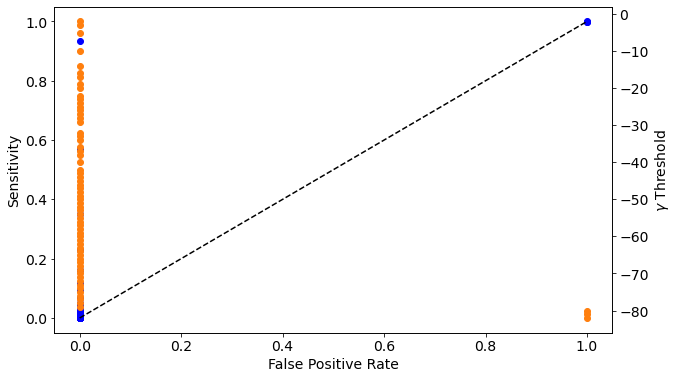

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
ax1 = fig.add_subplot(111)
ax2 = ax1.twinx()

ax1.plot(fpr, tpr, 'ob')
# ax1.plot(fpr, thresholds, 'o')
ax1.plot([0,1],[0,1], '--k')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("Sensitivity")

ax2.plot(fpr, -thresholds, 'o', color='tab:orange')
ax2.set_ylabel("$\gamma$ Threshold")
